In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
%matplotlib inline

In [3]:
df= pd.read_csv("customer_churn.csv");    print(df.shape)
df.head()

(900, 10)


,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [4]:
df.drop(['Names', 'Onboard_date', 'Location', 'Company'], axis=1, inplace=True)

In [5]:
df.dtypes

Age                float64
Total_Purchase     float64
Account_Manager      int64
Years              float64
Num_Sites          float64
Churn                int64
dtype: object

In [6]:
X = df.drop("Churn", axis=1)
y= df['Churn']

In [7]:
# Sigmoid funtion
def sigmoid(z):
    """
    z (array) : the prediction (f_wb = wx + b) ,
    funtion: perform a sizmoid cal and return the results.
    """
    return 1 /(1 + np.exp(-z))

In [8]:
def cost_function(X, y , w):
    m = len(y)
    z = sigmoid(X.dot(w))
    error = ( y * np.log(z) + (1- y)*np.log(1- z))
    j_wb = -1/ m * sum(error)
    grad = 1/m * X.T.dot(z- y)

    return j_wb, grad

In [22]:
def gradient_descent(X, y, w, alpha, iteration):
    cost_history = np.zeros(iteration)
    for i in range(iteration):
        cost, grad = cost_function(X, y, w)
        w -= alpha * grad
        cost_history[i] = cost
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:4.2f}")
    return w , cost_history

In [10]:
def predict(X, w):
    return sigmoid(X.dot(w))

In [31]:
def accuracy(y_true, y_pred):
    acc= sum(y_true == y_pred) / len(y_true) * 100
    return acc

In [12]:
X_train , X_test, y_train, y_test = train_test_split(X, y , test_size=0.2 , random_state= 42)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

In [23]:
dj_dw, cost_history = gradient_descent(X_train, y_train, np.zeros(X_train.shape[1]), alpha= 0.01, iteration= 1000)

Iteration 0: Cost 0.69
Iteration 100: Cost 0.57
Iteration 200: Cost 0.49
Iteration 300: Cost 0.44
Iteration 400: Cost 0.40
Iteration 500: Cost 0.38
Iteration 600: Cost 0.36
Iteration 700: Cost 0.35
Iteration 800: Cost 0.33
Iteration 900: Cost 0.33


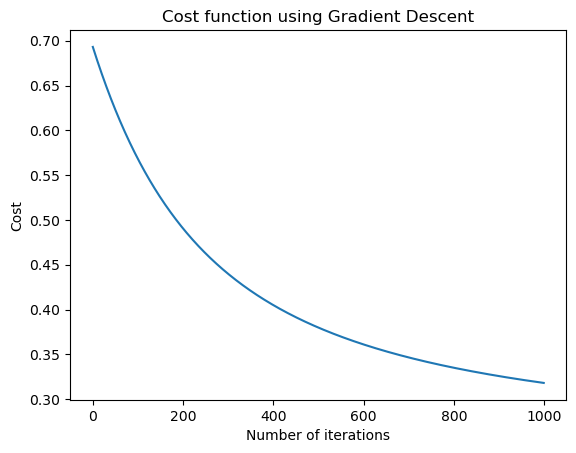

In [26]:
plt.plot(range(1000), cost_history)
plt.xlabel("Number of iterations")
plt.ylabel("Cost")
plt.title("Cost function using Gradient Descent")
plt.show()

In [27]:
# Prediction threshold
y_pred = predict(X_test, dj_dw)
y_pred = [1 if i> 0.5 else 0 for i in y_pred]


In [33]:
accuracy(y_test, y_pred)

88.88888888888889

In [34]:
test_df = pd.read_csv('new_customers_1.csv')
test_df.drop(['Names', 'Onboard_date', 'Location', 'Company'], axis=1, inplace=True)
test_df.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,37.0,9935.53,1,7.71,8.0
1,23.0,7526.94,1,9.28,15.0
2,65.0,100.00,1,1.00,15.0
3,32.0,6487.50,0,9.40,14.0
4,32.0,13147.71,1,10.00,8.0


In [35]:
X_new = scaler.transform(test_df)
X_new = np.c_[np.ones((X_new.shape[0], 1)), X_new]
y_pred_new = predict(X_new, dj_dw)
y_pred_new = [1 if i> 0.5 else 0 for i in y_pred_new]

test_df['Churn'] = y_pred_new
test_df.to_csv('new_customers_1_with_predictions.csv', index=False)

<h1>LOGISTIC REGRESSION</h1>

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [47]:
lr = LogisticRegression(random_state=42, verbose=3, n_jobs=-1)

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga','newton-cg', 'lbfgs', 'sag']
}

grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)


[LibLinear]

c:\ProgramData\anaconda3\envs\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


,estimator,"LogisticRegre...42, verbose=3)"
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'saga', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [51]:
print(grid_search.best_params_)
print(grid_search.best_estimator_)

{'C': 100, 'solver': 'liblinear'}
LogisticRegression(C=100, n_jobs=-1, random_state=42, solver='liblinear',
                   verbose=3)


In [52]:
pd.DataFrame(grid_search.cv_results_).sort_values(by='rank_test_score', ascending=True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_solver,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
24,0.097263,0.002733,0.002914,0.000607,100.00,sag,"{'C': 100, 'solver': 'sag'}",0.891667,0.891667,0.908333,0.897222,0.007857,1
22,0.088840,0.027337,0.004042,0.000185,100.00,newton-cg,"{'C': 100, 'solver': 'newton-cg'}",0.891667,0.891667,0.908333,0.897222,0.007857,1
21,0.164443,0.016755,0.004939,0.001248,100.00,saga,"{'C': 100, 'solver': 'saga'}",0.891667,0.891667,0.908333,0.897222,0.007857,1
20,0.011446,0.007494,0.004348,0.001549,100.00,liblinear,"{'C': 100, 'solver': 'liblinear'}",0.891667,0.891667,0.908333,0.897222,0.007857,1
23,0.043808,0.004614,0.004113,0.000258,100.00,lbfgs,"{'C': 100, 'solver': 'lbfgs'}",0.891667,0.891667,0.908333,0.897222,0.007857,1
19,0.298133,0.074354,0.004684,0.000260,10.00,sag,"{'C': 10, 'solver': 'sag'}",0.887500,0.891667,0.908333,0.895833,0.009001,6
18,0.262286,0.046576,0.004365,0.000264,10.00,lbfgs,"{'C': 10, 'solver': 'lbfgs'}",0.887500,0.891667,0.908333,0.895833,0.009001,6
17,0.173918,0.075188,0.004178,0.000200,10.00,newton-cg,"{'C': 10, 'solver': 'newton-cg'}",0.887500,0.891667,0.908333,0.895833,0.009001,6
16,0.269636,0.071434,0.003558,0.000161,10.00,saga,"{'C': 10, 'solver': 'saga'}",0.887500,0.891667,0.908333,0.895833,0.009001,6
15,0.009545,0.000900,0.004436,0.000388,10.00,liblinear,"{'C': 10, 'solver': 'liblinear'}",0.887500,0.891667,0.908333,0.895833,0.009001,6


In [56]:
y_pred_grid = grid_search.best_estimator_.predict(X_new)

test_df['Churn'] = y_pred_grid

test_df.to_csv('new_customers_1_with_predictions_grid_search.csv', index=False)